In [2]:
import numpy as np 
import matplotlib.pyplot as plt
import torch 
import torchvision 
from torchvision import transforms, datasets
import os 
from PIL import Image, UnidentifiedImageError
from collections import Counter
import random
import torch.nn as nn 
import torch.optim as optim
from torch.utils.data import DataLoader, ConcatDataset
from sklearn.metrics import (roc_auc_score, roc_curve,
                             confusion_matrix, ConfusionMatrixDisplay,
                             f1_score, balanced_accuracy_score)

In [1]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Preprocessing

In [3]:
# preprocessing only, no normalization yet
base_transform_no_norm = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

train_dataset_no_norm = datasets.ImageFolder(
    root='data_project_gray/train',
    transform=base_transform_no_norm
)

def compute_mean_std(dataset):
    pixel_sum = 0.0
    pixel_squared_sum = 0.0
    total_pixels = 0
    valid_images = 0

    for i in range(len(dataset)):
        try:
            image, _ = dataset[i]
            pixel_sum += image.sum().item()
            pixel_squared_sum += (image ** 2).sum().item()
            total_pixels += image.numel()
            valid_images += 1
        except (UnidentifiedImageError, OSError):
            print(f"Skipping corrupted image at index {i}")
            continue

    mean = pixel_sum / total_pixels
    std = ((pixel_squared_sum / total_pixels) - mean**2) ** 0.5

    print("Valid training images used:", valid_images)
    print("Training mean:", round(mean, 4))
    print("Training std:", round(std, 4))

    return mean, std

train_mean, train_std = compute_mean_std(train_dataset_no_norm)

Skipping corrupted image at index 381
Valid training images used: 749
Training mean: 0.606
Training std: 0.1944


In [4]:
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((128, 128)),
    
    # augmentation
    transforms.RandomRotation(degrees=10, fill=0),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05),
        fill=0
    ),
    
    transforms.ToTensor(),
    transforms.Normalize(mean=[train_mean], std=[train_std])
])

eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[train_mean], std=[train_std])
])

In [5]:
train_dataset = datasets.ImageFolder(
    root='data_project_gray/train',
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    root='data_project_gray/val',
    transform=eval_transform
)

test_dataset = datasets.ImageFolder(
    root='data_project_gray/test',
    transform=eval_transform
)

In [6]:
from torch.utils.data import Dataset
from PIL import UnidentifiedImageError

class SafeImageFolder(Dataset):
    def __init__(self, root, transform=None):
        self.dataset = datasets.ImageFolder(root=root, transform=transform)
        self.transform = transform
        # filter out corrupted images
        self.valid_indices = []
        for i in range(len(self.dataset)):
            path, _ = self.dataset.samples[i]
            try:
                with open(path, 'rb') as f:
                    Image.open(f).verify()
                self.valid_indices.append(i)
            except (UnidentifiedImageError, OSError):
                print(f"Skipping corrupted image: {path}")

        self.classes = self.dataset.classes
        self.class_to_idx = self.dataset.class_to_idx
        self.targets = [self.dataset.targets[i] for i in self.valid_indices]

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        return self.dataset[self.valid_indices[idx]]

In [7]:
train_dataset = SafeImageFolder(root='data_project_gray/train', transform=train_transform)
val_dataset   = SafeImageFolder(root='data_project_gray/val',   transform=eval_transform)
test_dataset  = SafeImageFolder(root='data_project_gray/test',  transform=eval_transform)

Skipping corrupted image: data_project_gray/train\0\9184495L.png
Skipping corrupted image: data_project_gray/val\1\9294761L.png


In [8]:
from torch.utils.data import DataLoader

batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [9]:
images, labels = next(iter(train_loader))

print("Batch image shape:", images.shape)
print("Batch labels shape:", labels.shape)
print("Min pixel value:", images.min().item())
print("Max pixel value:", images.max().item())

Batch image shape: torch.Size([32, 1, 128, 128])
Batch labels shape: torch.Size([32])
Min pixel value: -3.1172120571136475
Max pixel value: 1.9054900407791138


In [10]:
# ImageFolder stores labels in .targets
train_labels = torch.tensor(train_dataset.targets)
n_neg = (train_labels == 0).sum().item()  # Healthy
n_pos = (train_labels == 1).sum().item()  # OA

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsing device: {device}")

# Up-weight the minority class in the loss
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float).to(device)
print(f"pos_weight: {pos_weight.item():.2f}")


Using device: cpu
pos_weight: 2.00


# Baseline model

### Model architecture

In [19]:
class Baseline(nn.Module):
    def __init__(self, dropout=0.5):
        super().__init__()

        # convolution part 
        self.conv = nn.Sequential(
            # Block 1
            nn.Conv2d(1, 32, kernel_size=3, padding=1),   # (1,128,128) -> (32,128,128): one ingoing channel and one outgoing
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),                               # -> (32,64,64)

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # -> (64,64,64)
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),                               # -> (64,32,32)

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1), # -> (128,32,32)
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),                               # -> (128,16,16)
        )

        # connected part 
        self.conn = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 1)
        )

    def forward(self,x):
        return self.conn(self.conv(x)).squeeze(1)
    
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Baseline(dropout=0.5).to(device)
print(model) 
print(f"\nTrainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Baseline(
  (conv): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conn): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, i

In [22]:
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=1e-3) #weight_decay=1e-4

def calculate_metrics(loader, model, threshold=0.5):
    model.eval() # turning the model in evaluation mode (important for dropout, batchnorm, ...) 
    all_probs, all_labels = [], []
    with torch.no_grad(): # disabling gradient calculation because we aren't updating the model 
        for X, y in loader:
            X = X.to(device)
            logits = model(X)
            probs  = torch.sigmoid(logits).cpu().numpy() # gives a percentage of how likely sick 
            all_probs.extend(probs)
            all_labels.extend(y.numpy())

    all_probs  = np.array(all_probs)
    all_labels = np.array(all_labels)
    all_preds  = (all_probs >= threshold).astype(int) # if the probability is above 50% we predict sick, otherwise healthy 

    return {
        "accuracy":  accuracy_score(all_labels, all_preds),
        "precision": precision_score(all_labels, all_preds, zero_division=0),
        "recall":    recall_score(all_labels, all_preds, zero_division=0),
        "f1":        f1_score(all_labels, all_preds, zero_division=0),
        "auc":       roc_auc_score(all_labels, all_probs),
        "probs":     all_probs,
        "labels":    all_labels, 
    }

### Training the model

In [13]:
# hyperparameters 1
# Epochs = 20, learning rate = 1e-3, weight decay = nothing, dropout = 0.5 
EPOCHS = 20 # an epoch is one complete pass of the training dataset through the neural network 
history = {
    "train_loss":     [],
    "val_loss":       [],
    "val_accuracy":   [],
    "val_precision":  [],
    "val_recall":     [],
    "val_f1":         [],
    "val_auc":        []
}

for epoch in range(1, EPOCHS + 1):
    # train, like a study session 
    model.train()
    train_loss = 0.0
    for X, y in train_loader: # the loader divides the big dataset into batches, otherwise too much data at once 
        X, y = X.to(device), y.to(device).float()
        optimizer.zero_grad()
        loss = criterion(model(X), y) # loss calculation with loss function above specified 
        loss.backward() # model works backwards from the error to see which neuron is responsible for error 
        optimizer.step() # adjusting of the weights 
        train_loss += loss.item() * len(y)
    train_loss /= len(train_dataset) # dividing by number of samples to get average per sample 

    # validate
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(device), y.to(device).float()
            val_loss += criterion(model(X), y).item() * len(y)
    val_loss /= len(val_dataset)

    metrics = calculate_metrics(val_loader, model)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(metrics["accuracy"])
    history["val_precision"].append(metrics["precision"])
    history["val_recall"].append(metrics["recall"])
    history["val_f1"].append(metrics["f1"])
    history["val_auc"].append(metrics["auc"])

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
      f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
      f"Acc: {metrics['accuracy']:.3f} | Prec: {metrics['precision']:.3f} | "
      f"Rec: {metrics['recall']:.3f} | F1: {metrics['f1']:.3f} | "
      f"AUC: {metrics['auc']:.3f}")
    
    # overfitting is happening when train loss is decreasing but validation loss is increasing 

Epoch 01/20 | Train Loss: 3.5693 | Val Loss: 0.9070 | Acc: 0.532 | Prec: 0.451 | Rec: 0.887 | F1: 0.598 | AUC: 0.676
Epoch 02/20 | Train Loss: 0.9364 | Val Loss: 0.9827 | Acc: 0.614 | Prec: 0.512 | Rec: 0.339 | F1: 0.408 | AUC: 0.635
Epoch 03/20 | Train Loss: 0.9161 | Val Loss: 1.0293 | Acc: 0.652 | Prec: 0.889 | Rec: 0.129 | F1: 0.225 | AUC: 0.672
Epoch 04/20 | Train Loss: 0.9070 | Val Loss: 0.9627 | Acc: 0.658 | Prec: 0.611 | Rec: 0.355 | F1: 0.449 | AUC: 0.704
Epoch 05/20 | Train Loss: 0.8889 | Val Loss: 0.9487 | Acc: 0.671 | Prec: 0.596 | Rec: 0.500 | F1: 0.544 | AUC: 0.702
Epoch 06/20 | Train Loss: 0.8932 | Val Loss: 0.9290 | Acc: 0.658 | Prec: 0.643 | Rec: 0.290 | F1: 0.400 | AUC: 0.728
Epoch 07/20 | Train Loss: 0.8975 | Val Loss: 0.9445 | Acc: 0.677 | Prec: 0.596 | Rec: 0.548 | F1: 0.571 | AUC: 0.684
Epoch 08/20 | Train Loss: 0.8861 | Val Loss: 0.8964 | Acc: 0.728 | Prec: 0.656 | Rec: 0.645 | F1: 0.650 | AUC: 0.738
Epoch 09/20 | Train Loss: 0.8441 | Val Loss: 0.8461 | Acc: 0.741

On the graph below we see that this seems to be a good start for our baseline model. For the metrics, I chose to look at the precision, F1 score, recall and ROC. We don't look at the accuracy because there is a high chance that it will be biased. This bias presents itself because the dataset isn't divided eqally into healthy and not healthy but presents a bias to the healthy class. 

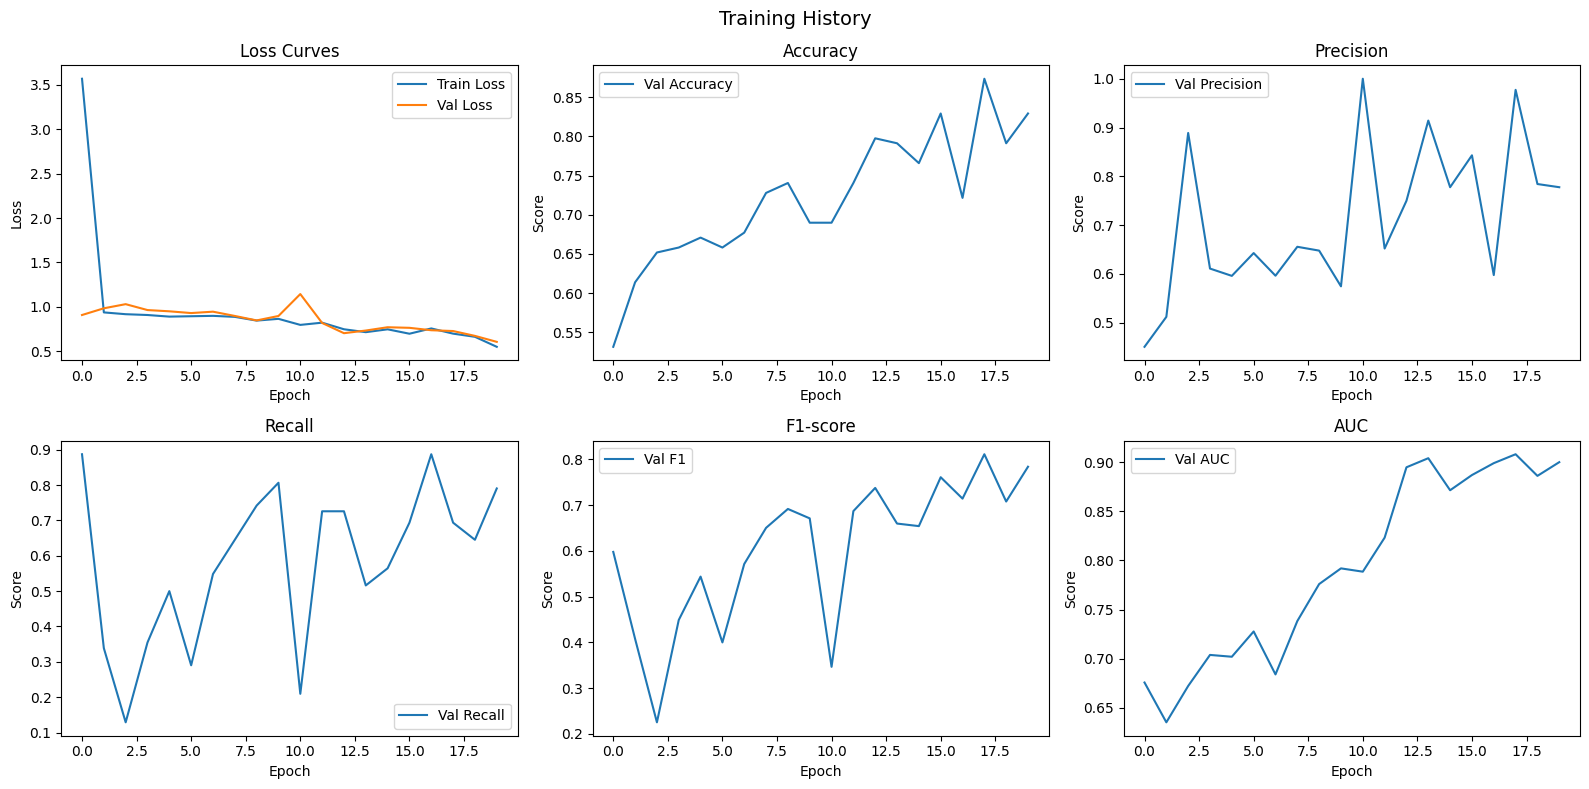

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

axes[0, 0].plot(history["train_loss"], label="Train Loss")
axes[0, 0].plot(history["val_loss"],   label="Val Loss")
axes[0, 0].set_xlabel("Epoch"); axes[0, 0].set_ylabel("Loss")
axes[0, 0].set_title("Loss Curves"); axes[0, 0].legend()

axes[0, 1].plot(history["val_accuracy"], label="Val Accuracy")
axes[0, 1].set_xlabel("Epoch"); axes[0, 1].set_ylabel("Score")
axes[0, 1].set_title("Accuracy"); axes[0, 1].legend()

axes[0, 2].plot(history["val_precision"], label="Val Precision")
axes[0, 2].set_xlabel("Epoch"); axes[0, 2].set_ylabel("Score")
axes[0, 2].set_title("Precision"); axes[0, 2].legend()

axes[1, 0].plot(history["val_recall"], label="Val Recall")
axes[1, 0].set_xlabel("Epoch"); axes[1, 0].set_ylabel("Score")
axes[1, 0].set_title("Recall"); axes[1, 0].legend()

axes[1, 1].plot(history["val_f1"], label="Val F1")
axes[1, 1].set_xlabel("Epoch"); axes[1, 1].set_ylabel("Score")
axes[1, 1].set_title("F1-score"); axes[1, 1].legend()

axes[1, 2].plot(history["val_auc"], label="Val AUC")
axes[1, 2].set_xlabel("Epoch"); axes[1, 2].set_ylabel("Score")
axes[1, 2].set_title("AUC"); axes[1, 2].legend()

plt.suptitle("Training History", fontsize=14)
plt.tight_layout()
plt.show()

In [20]:
# hyperparameters 2
# Epochs = 30, learning rate = 1e-3, weight decay = nothing, dropout = 0.5 
# trying the loss function without the weights 
EPOCHS = 30 # an epoch is one complete pass of the training dataset through the neural network 
history = {
    "train_loss":     [],
    "val_loss":       [],
    "val_accuracy":   [],
    "val_precision":  [],
    "val_recall":     [],
    "val_f1":         [],
    "val_auc":        []
}

for epoch in range(1, EPOCHS + 1):
    # train, like a study session 
    model.train()
    train_loss = 0.0
    for X, y in train_loader: # the loader divides the big dataset into batches, otherwise too much data at once 
        X, y = X.to(device), y.to(device).float()
        optimizer.zero_grad()
        loss = criterion(model(X), y) # loss calculation with loss function above specified 
        loss.backward() # model works backwards from the error to see which neuron is responsible for error 
        optimizer.step() # adjusting of the weights 
        train_loss += loss.item() * len(y)
    train_loss /= len(train_dataset) # dividing by number of samples to get average per sample 

    # validate
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(device), y.to(device).float()
            val_loss += criterion(model(X), y).item() * len(y)
    val_loss /= len(val_dataset)

    metrics = calculate_metrics(val_loader, model)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(metrics["accuracy"])
    history["val_precision"].append(metrics["precision"])
    history["val_recall"].append(metrics["recall"])
    history["val_f1"].append(metrics["f1"])
    history["val_auc"].append(metrics["auc"])

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
      f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
      f"Acc: {metrics['accuracy']:.3f} | Prec: {metrics['precision']:.3f} | "
      f"Rec: {metrics['recall']:.3f} | F1: {metrics['f1']:.3f} | "
      f"AUC: {metrics['auc']:.3f}")
    
    # overfitting is happening when train loss is decreasing but validation loss is increasing 

Epoch 01/30 | Train Loss: 0.7266 | Val Loss: 0.6974 | Acc: 0.430 | Prec: 0.377 | Rec: 0.694 | F1: 0.489 | AUC: 0.493
Epoch 02/30 | Train Loss: 0.7230 | Val Loss: 0.7026 | Acc: 0.418 | Prec: 0.371 | Rec: 0.694 | F1: 0.483 | AUC: 0.467
Epoch 03/30 | Train Loss: 0.7309 | Val Loss: 0.7040 | Acc: 0.418 | Prec: 0.371 | Rec: 0.694 | F1: 0.483 | AUC: 0.456
Epoch 04/30 | Train Loss: 0.7282 | Val Loss: 0.7037 | Acc: 0.418 | Prec: 0.371 | Rec: 0.694 | F1: 0.483 | AUC: 0.459
Epoch 05/30 | Train Loss: 0.7278 | Val Loss: 0.7038 | Acc: 0.418 | Prec: 0.371 | Rec: 0.694 | F1: 0.483 | AUC: 0.458
Epoch 06/30 | Train Loss: 0.7339 | Val Loss: 0.7034 | Acc: 0.418 | Prec: 0.371 | Rec: 0.694 | F1: 0.483 | AUC: 0.462
Epoch 07/30 | Train Loss: 0.7286 | Val Loss: 0.7040 | Acc: 0.418 | Prec: 0.371 | Rec: 0.694 | F1: 0.483 | AUC: 0.457
Epoch 08/30 | Train Loss: 0.7321 | Val Loss: 0.7043 | Acc: 0.424 | Prec: 0.376 | Rec: 0.710 | F1: 0.492 | AUC: 0.455
Epoch 09/30 | Train Loss: 0.7317 | Val Loss: 0.7041 | Acc: 0.418

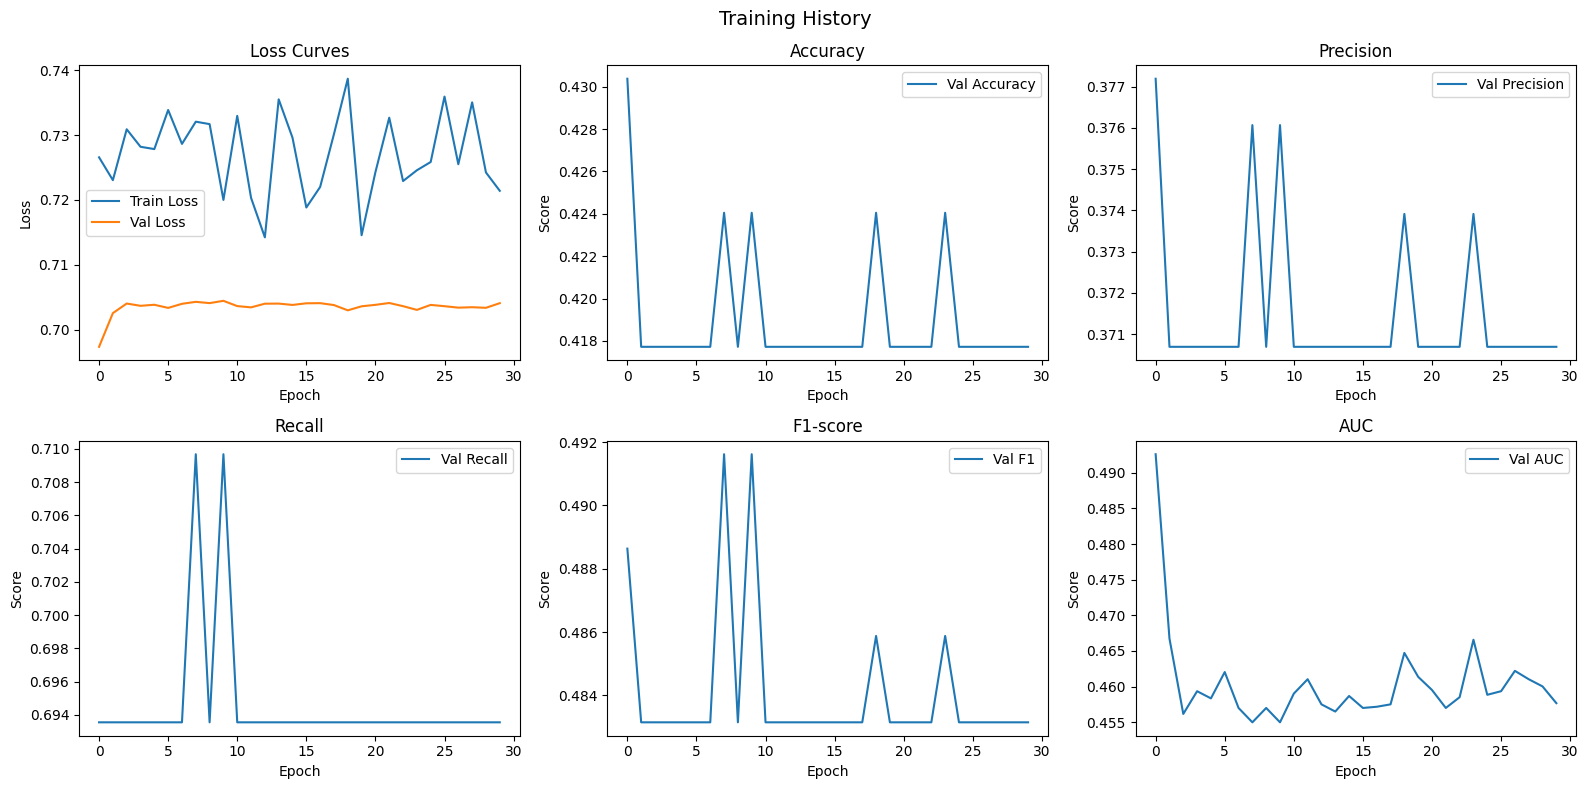

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

axes[0, 0].plot(history["train_loss"], label="Train Loss")
axes[0, 0].plot(history["val_loss"],   label="Val Loss")
axes[0, 0].set_xlabel("Epoch"); axes[0, 0].set_ylabel("Loss")
axes[0, 0].set_title("Loss Curves"); axes[0, 0].legend()

axes[0, 1].plot(history["val_accuracy"], label="Val Accuracy")
axes[0, 1].set_xlabel("Epoch"); axes[0, 1].set_ylabel("Score")
axes[0, 1].set_title("Accuracy"); axes[0, 1].legend()

axes[0, 2].plot(history["val_precision"], label="Val Precision")
axes[0, 2].set_xlabel("Epoch"); axes[0, 2].set_ylabel("Score")
axes[0, 2].set_title("Precision"); axes[0, 2].legend()

axes[1, 0].plot(history["val_recall"], label="Val Recall")
axes[1, 0].set_xlabel("Epoch"); axes[1, 0].set_ylabel("Score")
axes[1, 0].set_title("Recall"); axes[1, 0].legend()

axes[1, 1].plot(history["val_f1"], label="Val F1")
axes[1, 1].set_xlabel("Epoch"); axes[1, 1].set_ylabel("Score")
axes[1, 1].set_title("F1-score"); axes[1, 1].legend()

axes[1, 2].plot(history["val_auc"], label="Val AUC")
axes[1, 2].set_xlabel("Epoch"); axes[1, 2].set_ylabel("Score")
axes[1, 2].set_title("AUC"); axes[1, 2].legend()

plt.suptitle("Training History", fontsize=14)
plt.tight_layout()
plt.show()

## final baseline

#### chosen hyperparameters
dropout rate: 0.5

learning rate: 0.0001

optimizer: Adam

loss function: BCEWithLogitsLoss

#### chosen metrics
F1-score

precision

recall

ROC 

Epoch 01/30 | Train Loss: 4.5391
Epoch 02/30 | Train Loss: 1.0804
Epoch 03/30 | Train Loss: 0.9263
Epoch 04/30 | Train Loss: 0.9034
Epoch 05/30 | Train Loss: 0.9007
Epoch 06/30 | Train Loss: 0.8725
Epoch 07/30 | Train Loss: 0.8365
Epoch 08/30 | Train Loss: 0.8040
Epoch 09/30 | Train Loss: 0.7463
Epoch 10/30 | Train Loss: 0.7115
Epoch 11/30 | Train Loss: 0.7128
Epoch 12/30 | Train Loss: 0.6961
Epoch 13/30 | Train Loss: 0.6574
Epoch 14/30 | Train Loss: 0.6618
Epoch 15/30 | Train Loss: 0.6484
Epoch 16/30 | Train Loss: 0.5870
Epoch 17/30 | Train Loss: 0.5253
Epoch 18/30 | Train Loss: 0.6284
Epoch 19/30 | Train Loss: 0.6451
Epoch 20/30 | Train Loss: 0.5800
Epoch 21/30 | Train Loss: 0.5562
Epoch 22/30 | Train Loss: 0.4789
Epoch 23/30 | Train Loss: 0.4985
Epoch 24/30 | Train Loss: 0.4752
Epoch 25/30 | Train Loss: 0.4716
Epoch 26/30 | Train Loss: 0.4051
Epoch 27/30 | Train Loss: 0.4392
Epoch 28/30 | Train Loss: 0.4326
Epoch 29/30 | Train Loss: 0.3960
Epoch 30/30 | Train Loss: 0.4293


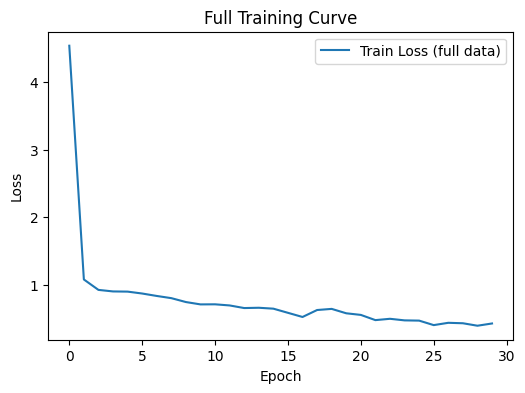

In [23]:
full_train_dataset = ConcatDataset([train_dataset, val_dataset])
full_train_loader  = DataLoader(full_train_dataset, batch_size=32, shuffle=True)

# Re-initialise model — important!
model = Baseline(dropout=0.5).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

full_history = {"train_loss": []}

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0.0
    for X, y in full_train_loader:
        X, y = X.to(device), y.to(device).float()
        optimizer.zero_grad()
        loss = criterion(model(X), y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(y)
    train_loss /= len(full_train_dataset)
    full_history["train_loss"].append(train_loss)
    print(f"Epoch {epoch:02d}/{EPOCHS} | Train Loss: {train_loss:.4f}")

plt.figure(figsize=(6, 4))
plt.plot(full_history["train_loss"], label="Train Loss (full data)")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Full Training Curve"); plt.legend()
plt.show()

In [24]:
torch.save(model.state_dict(), "baseline_model.pth")

model_loaded = Baseline(dropout=0.5).to(device)
model_loaded.load_state_dict(torch.load("baseline_model.pth", map_location=device))
model_loaded.eval()
print("Model saved and reloaded successfully.")

Model saved and reloaded successfully.


In [30]:
metrics = calculate_metrics(test_loader, model_loaded)
test_labels = metrics["labels"]
test_probs = metrics["probs"]
ROC = metrics["auc" ]
print(f"Test Accuracy:      {metrics['accuracy']:.4f}")
print(f"Test Precision:     {metrics['precision']:.4f}")
print(f"Test Recall:        {metrics['recall']:.4f}")
print(f"Test F1:            {metrics['f1']:.4f}")
print(f"Test AUC:           {metrics['auc']:.4f}")

Test Accuracy:      0.9110
Test Precision:     0.8246
Test Recall:        0.9400
Test F1:            0.8785
Test AUC:           0.9829


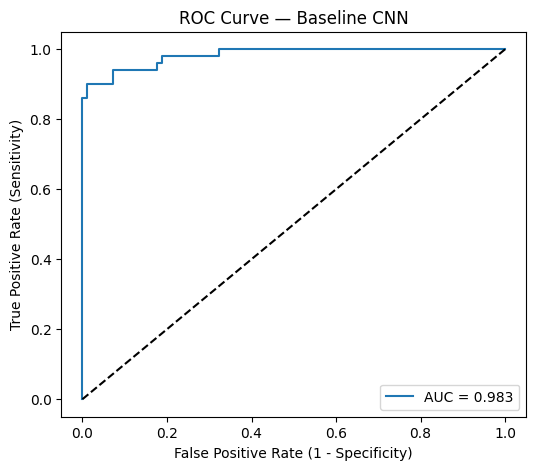

Chosen threshold: 0.677  (Sensitivity=0.900, Specificity=0.990)


In [ ]:
fpr, tpr, thresholds = roc_curve(test_labels, test_probs)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {ROC:.3f}")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("ROC Curve — Baseline CNN")
plt.legend()
plt.show()

# --- Threshold selection ---
# In a clinical screening context, missing an OA case (false negative) is more
# costly than a false alarm. So we prioritise high sensitivity.
# Choose the threshold where sensitivity >= 0.90.
target_sensitivity = 0.90
idx = np.where(tpr >= target_sensitivity)[0][0]
chosen_threshold = thresholds[idx]
print(f"Chosen threshold: {chosen_threshold:.3f}  "
      f"(Sensitivity={tpr[idx]:.3f}, Specificity={1-fpr[idx]:.3f})")

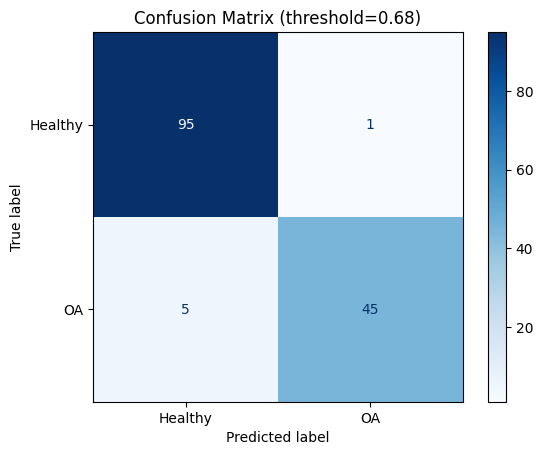

In [ ]:
test_preds = (test_probs >= chosen_threshold).astype(int)
cm = confusion_matrix(test_labels, test_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=["Healthy", "OA"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix (threshold={chosen_threshold:.2f})")
plt.show() 

In [34]:
def denormalize(tensor):
    """Reverse the normalization for display purposes."""
    return tensor * train_std + train_mean

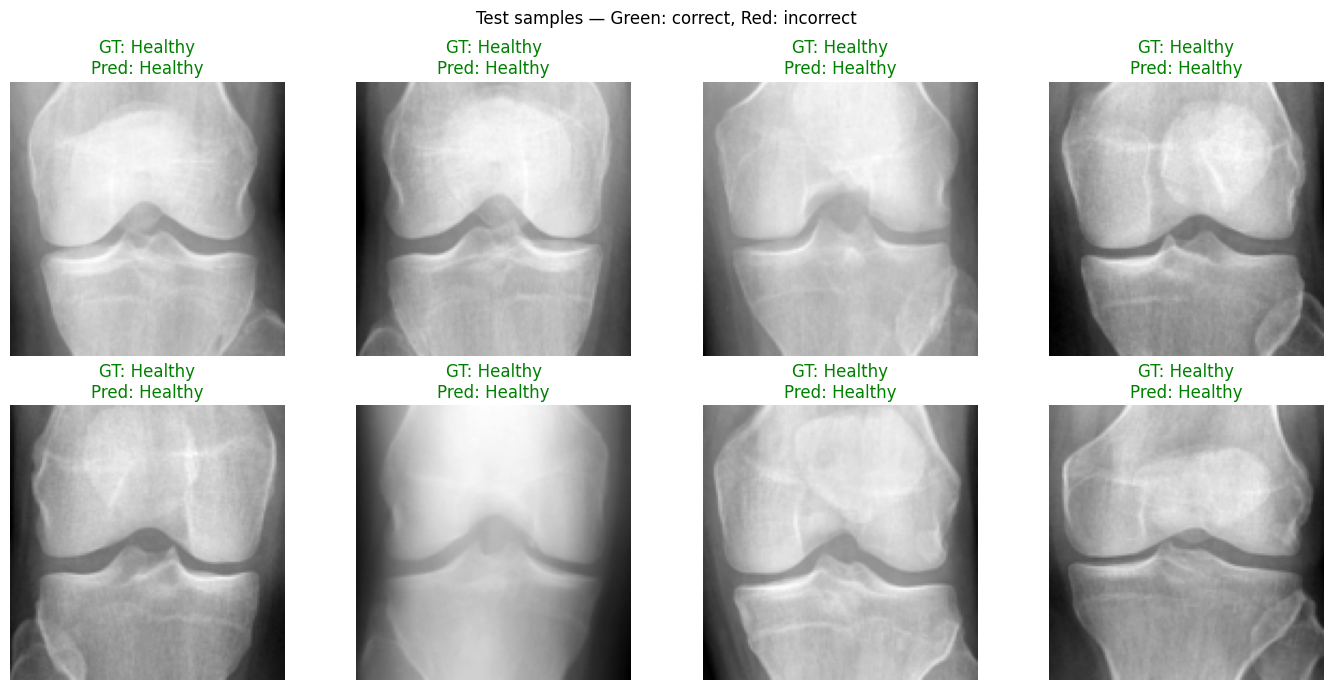

In [ ]:
# Collect a few samples from the test loader
model_loaded.eval()
samples, labels_list, preds_list = [], [], []

with torch.no_grad():
    for X, y in test_loader:
        logits = model_loaded(X.to(device))
        probs  = torch.sigmoid(logits).cpu().numpy()
        preds  = (probs >= chosen_threshold).astype(int)
        for i in range(len(X)):
            samples.append(X[i])
            labels_list.append(int(y[i]))
            preds_list.append(preds[i])
        if len(samples) >= 8:
            break

class_names = ["Healthy", "OA"]
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, img, gt, pred in zip(axes.flat, samples, labels_list, preds_list):
    # Denormalise for display (adapt denormalize() to your implementation)
    img_display = denormalize(img).squeeze().numpy()
    ax.imshow(img_display, cmap="gray")
    color = "green" if gt == pred else "red"
    ax.set_title(f"GT: {class_names[gt]}\nPred: {class_names[pred]}", color=color)
    ax.axis("off")
plt.suptitle("Test samples — Green: correct, Red: incorrect")
plt.tight_layout()
plt.show()